In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "sst2"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 67349
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence': 'hide new secretions from the parental units ',
 'label': 0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence']

"that 's far too tragic to merit such superficial treatment "

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence': Value('string'),
 'label': ClassLabel(names=['negative', 'positive']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 47]),
 'token_type_ids': torch.Size([32, 47]),
 'attention_mask': torch.Size([32, 47])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7323, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
outputs.keys()

odict_keys(['loss', 'logits', 'hidden_states', 'attentions'])

In [26]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Loading Trained Weights

In [27]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [28]:
from train_eval_func import eval_loop

In [29]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9311926605504587}

# 5. Similarity Analysis

In [30]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

### Using Training Data

In [31]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:26<00:00,  4.36it/s]

  Reps Similarity Stats:
    Average: 0.930428
    Highest: 0.990466
    Lowest:  0.838527

  Atts Similarity Stats:
    Average: 0.952101
    Highest: 0.996305
    Lowest:  0.795782
  Sublayer Similarity Stats:
    Average: 0.513620
    Highest: 0.872275
    Lowest:  0.168318


In [32]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

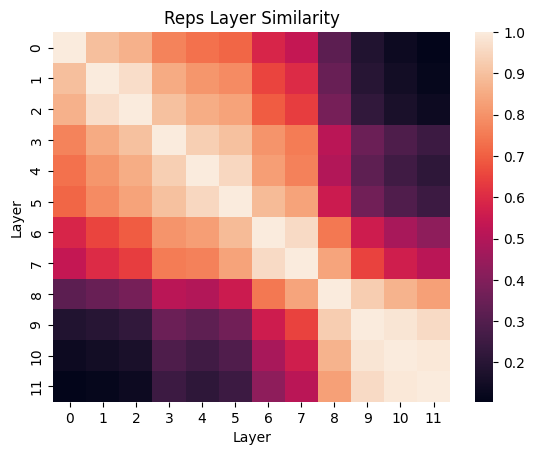

In [33]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

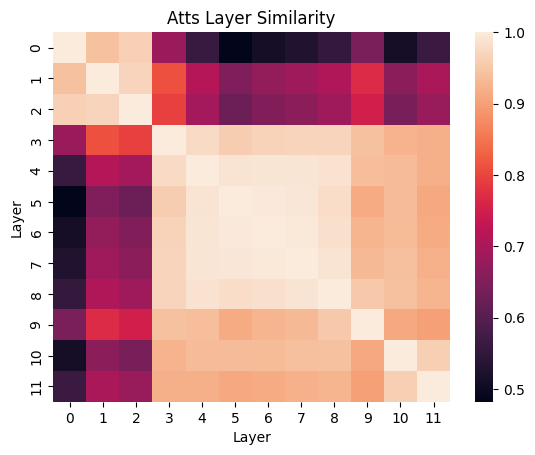

In [34]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

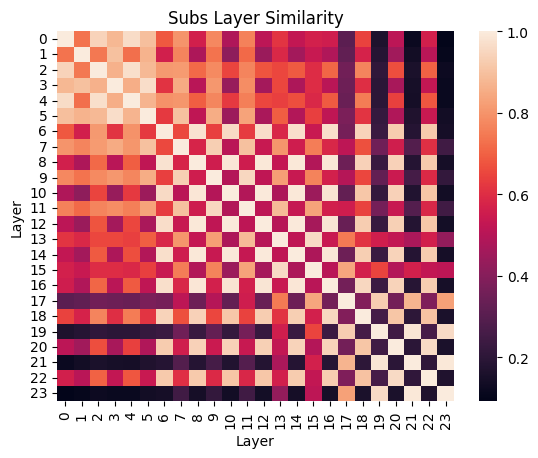

In [35]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

# 6. Layer Masking Register Function

In [36]:
from structure_prune_helper import compute_layer_importance_scores, register_importance_masks, remove_importance_masks

In [37]:
register_importance_masks(model, device, register_mha_layer=True, register_mlp_layer=True,
                         register_mha=True, register_mlp=True)

  Layer 0: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 1: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 2: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 3: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 4: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 5: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 6: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 7: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 8: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 9: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 10: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 11: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
mha_imp, ffn_imp, head_imp, neuron_imp = compute_layer_importance_scores(
            model, train_dataloader, device,
            compute_mha=True, compute_ffn=True,
            compute_heads=True, compute_neurons=True)

Computing importance (MHA layer, FFN layer, heads, neurons): 100%|██████████| 2105/2105 [02:11<00:00, 16.07it/s]


Layer Importance Summary:
          Layer     MHA(layer)     FFN(layer)    Heads(mean)  Neurons(mean)
  ---------------------------------------------------------------------------
  0                     1.0000         0.9959         0.0000         0.0000
  1                     0.6730         0.9201         0.0000         0.0000
  2                     0.6616         0.9786         0.0000         0.0000
  3                     0.4891         1.0000         0.0000         0.0000
  4                     0.5473         0.9769         0.0000         0.0000
  5                     0.5341         0.9858         0.0000         0.0000
  6                     0.5226         0.9293         0.0000         0.0000
  7                     0.6119         0.9138         0.0000         0.0000
  8                     0.5582         0.7289         0.0000         0.0000
  9                     0.3829         0.4346         0.0000         0.0000
  10                    0.3000         0.2956         0.000

In [39]:
import matplotlib.pyplot as plt
import numpy as np

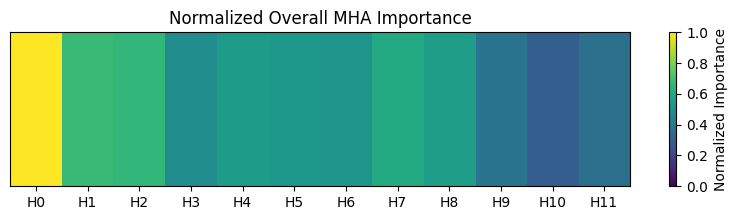

In [40]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    mha_imp.reshape(1, -1),   # or mha_imp[None, :]
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap='viridis'
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall MHA Importance")

plt.show()

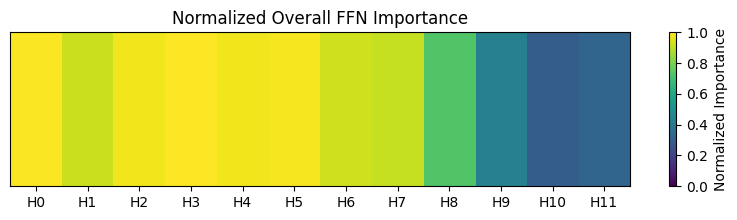

In [41]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    ffn_imp.reshape(1, -1),   # or mha_imp[None, :]
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap='viridis'
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [42]:
head_imp

[tensor([1.2247e-05, 1.1451e-05, 1.1003e-05, 9.6245e-06, 1.2421e-05, 1.1587e-05,
         1.0582e-05, 8.5630e-06, 1.4700e-05, 1.1684e-05, 1.5749e-05, 9.4430e-06],
        device='cuda:1'),
 tensor([7.9331e-06, 1.3693e-05, 4.9984e-06, 6.0193e-06, 1.2591e-05, 5.8904e-06,
         6.8236e-06, 8.2956e-06, 5.6180e-06, 6.1806e-06, 9.3723e-06, 9.4238e-06],
        device='cuda:1'),
 tensor([1.2429e-05, 1.0227e-05, 4.8654e-06, 3.8103e-06, 5.1198e-06, 5.1745e-06,
         8.4848e-06, 4.9549e-06, 4.3439e-06, 1.2494e-05, 6.0165e-06, 7.2737e-06],
        device='cuda:1'),
 tensor([5.3423e-06, 5.2793e-06, 5.3434e-06, 6.7034e-06, 3.8069e-06, 9.9114e-06,
         6.9280e-06, 4.6936e-06, 6.3642e-06, 1.0186e-05, 9.3243e-06, 7.5661e-06],
        device='cuda:1'),
 tensor([8.0713e-06, 3.7612e-06, 5.2034e-06, 3.6378e-06, 8.0370e-06, 8.2003e-06,
         8.0265e-06, 1.0539e-05, 4.1317e-06, 7.0958e-06, 6.6653e-06, 8.1330e-06],
        device='cuda:1'),
 tensor([6.3726e-06, 3.8598e-06, 2.9018e-06, 5.5999e-06

# 7. Visualize Individual Layer

In [43]:
def visualize_all_layers(head_importance):

    n_layers = len(head_importance)

    fig, axes = plt.subplots(
        3,
        4,
        figsize=(15,10)
    )

    axes = axes.flatten()

    for i in range(n_layers):

        data = head_importance[i].detach().cpu().numpy()

        axes[i].boxplot(data)

        axes[i].set_title(f"Layer {i}")

    plt.tight_layout()
    plt.show()

In [44]:
def visualize_layer_histogram(importance_scores, layer_idx):

    data = importance_scores[layer_idx].detach().cpu().numpy()

    plt.figure(figsize=(8,4))

    plt.hist(data, bins=30)

    plt.title(f"Layer {layer_idx}")
    plt.xlabel("Importance")
    plt.ylabel("Count")

    plt.show()

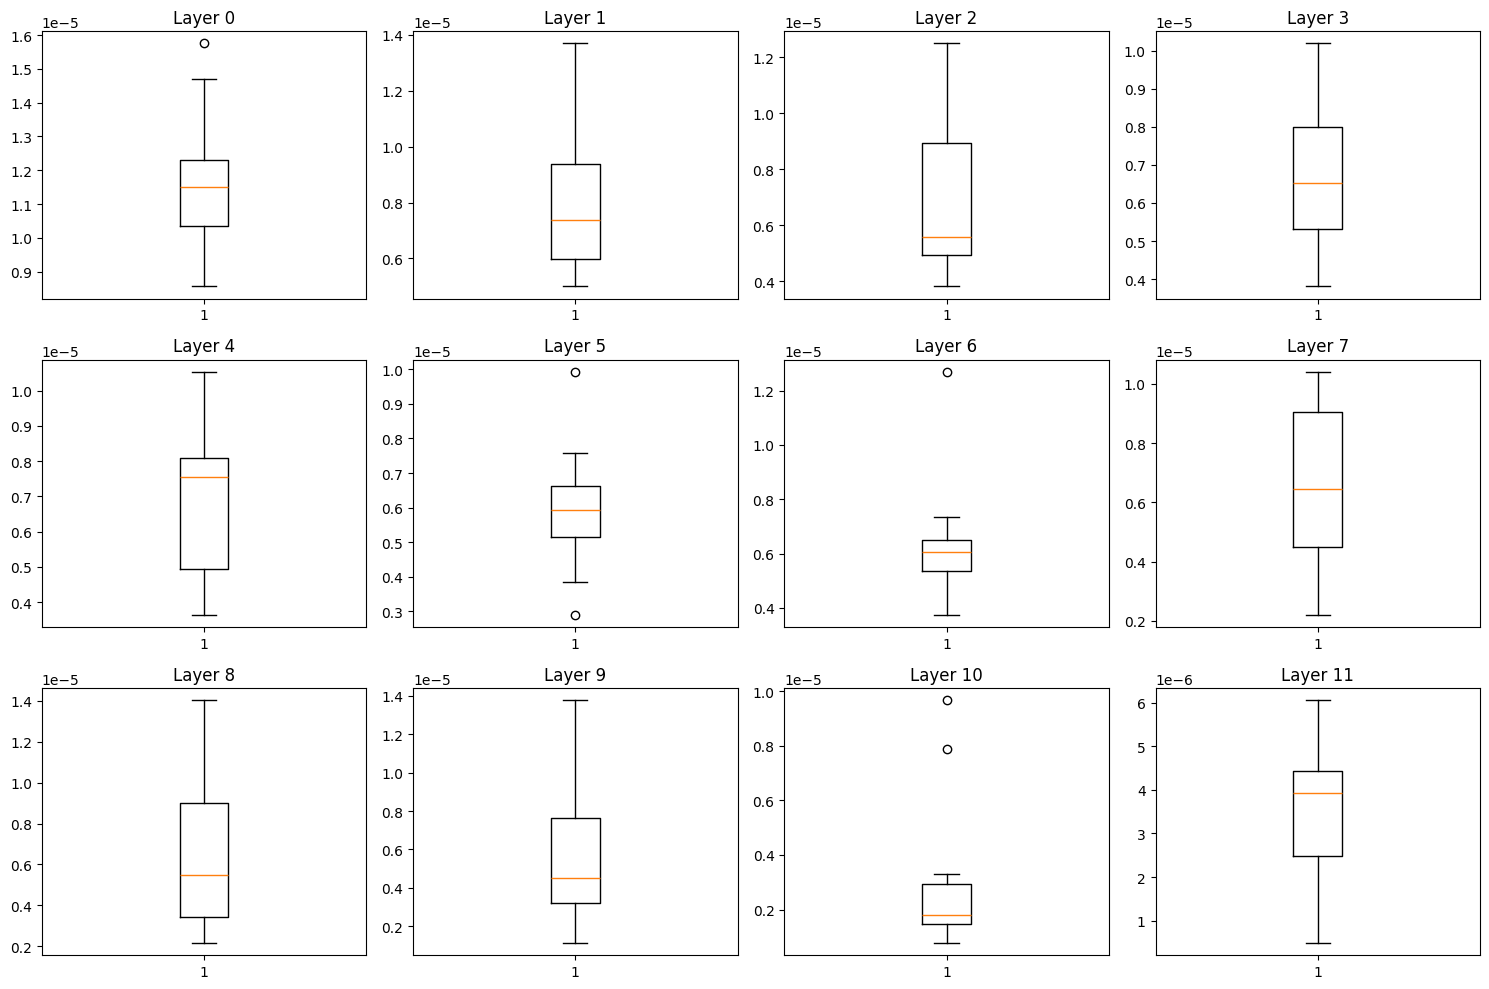

In [45]:
visualize_all_layers(head_imp)

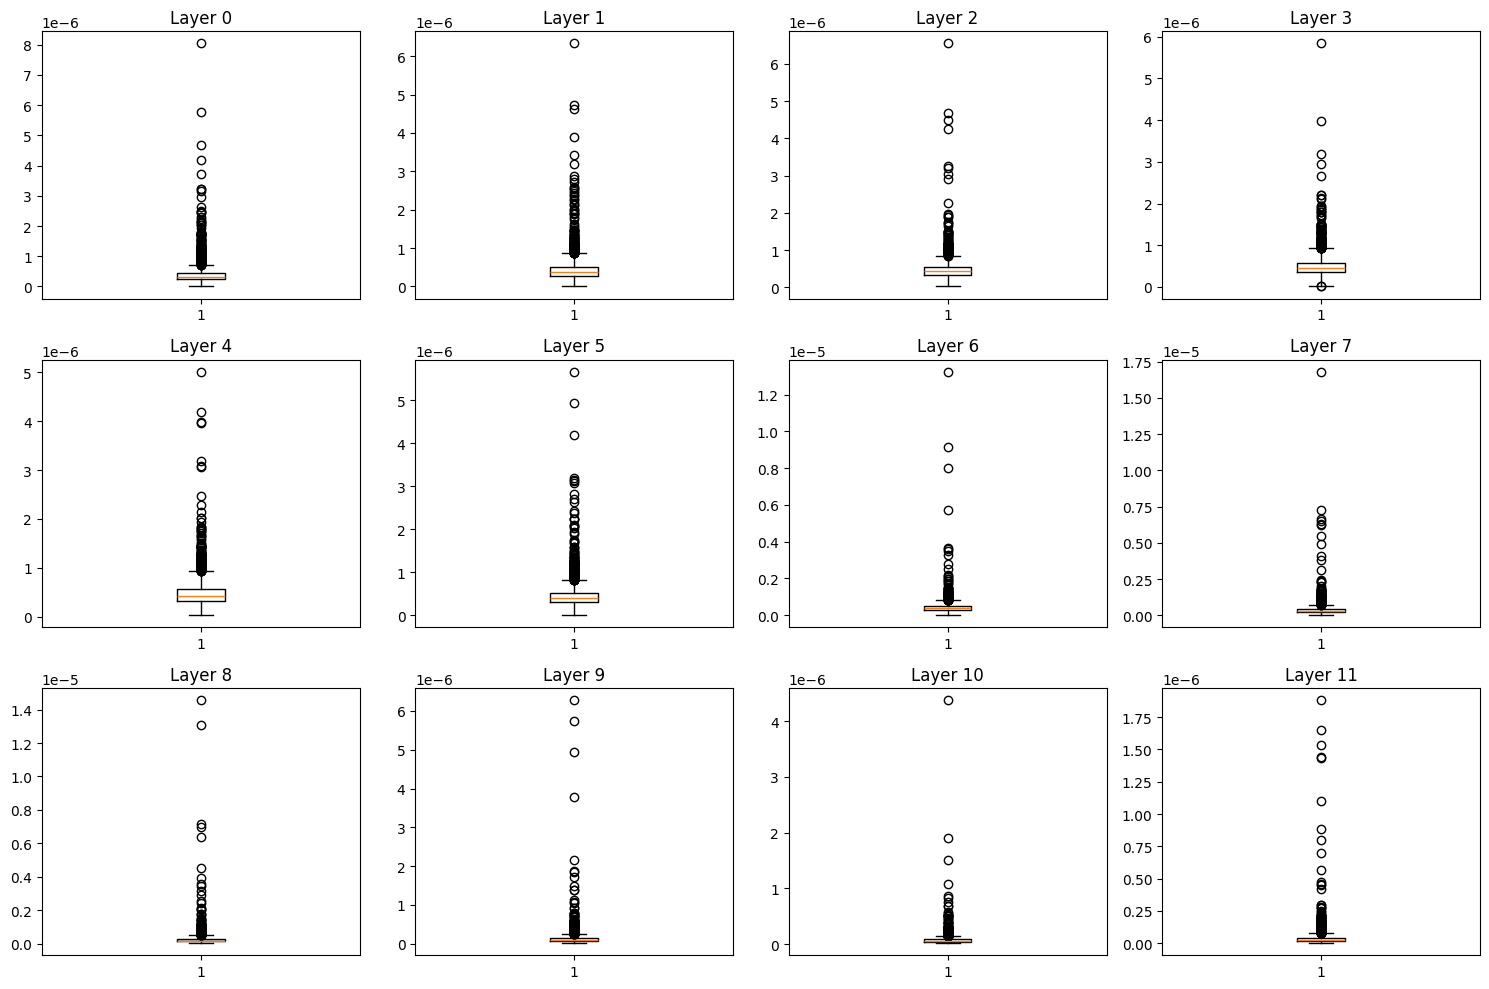

In [46]:
visualize_all_layers(neuron_imp)

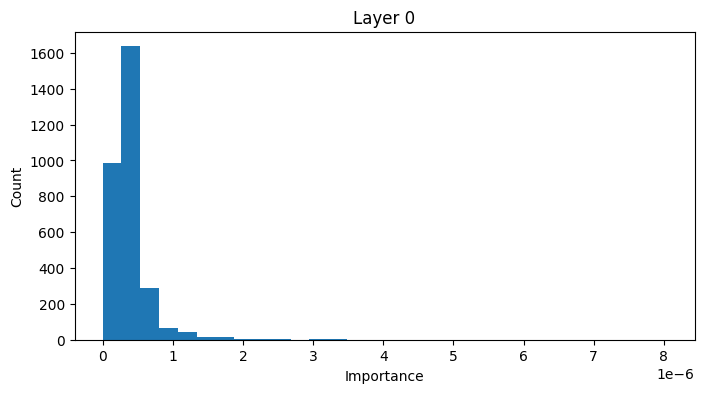

In [47]:
visualize_layer_histogram(neuron_imp, 0)

In [48]:
import matplotlib.pyplot as plt

def plot_head_distributions(head_importance):

    data = [
        h.detach().cpu().numpy()
        for h in head_importance
    ]

    plt.figure(figsize=(12, 6))

    box = plt.boxplot(
        data,
        patch_artist=True,
        showfliers=True
    )

    # Different color for each layer
    for i, patch in enumerate(box['boxes']):
        patch.set_facecolor(plt.cm.viridis(i / len(data)))

    plt.xlabel("Layer")
    plt.ylabel("Head Importance")
    plt.title("Attention Head Importance Distribution per Layer")

    plt.grid(alpha=0.3)
    plt.show()

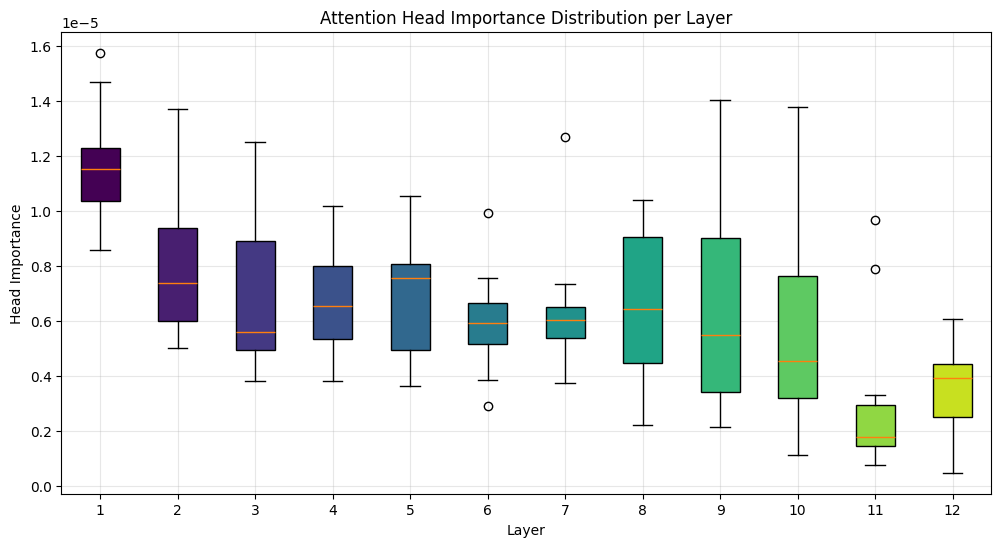

In [49]:
plot_head_distributions(head_imp)

In [50]:
def plot_ffn_distributions(neuron_importance):

    data = [
        h.detach().cpu().numpy()
        for h in neuron_importance
        if h is not None
    ]

    plt.figure(figsize=(12, 6))

    box = plt.boxplot(
        data,
        patch_artist=True,
        showfliers=False   # FFNs usually have many outliers
    )

    for i, patch in enumerate(box['boxes']):
        patch.set_facecolor(plt.cm.plasma(i / len(data)))

    plt.xlabel("Layer")
    plt.ylabel("Neuron Importance")
    plt.title("FFN Neuron Importance Distribution per Layer")

    plt.grid(alpha=0.3)
    plt.show()

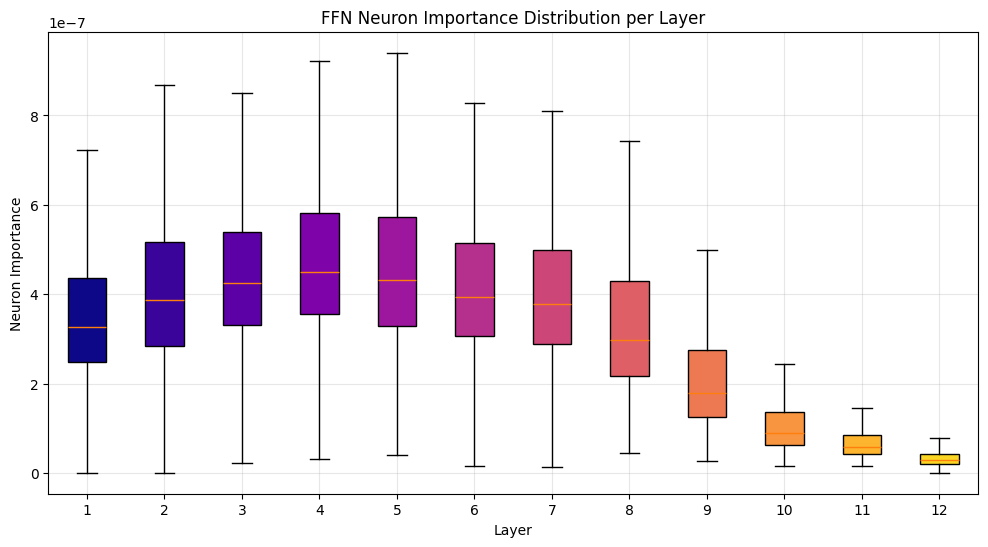

In [51]:
plot_ffn_distributions(neuron_imp)

In [52]:
def plot_ffn_mean_std(neuron_importance):

    means = []
    stds = []

    for h in neuron_importance:

        if h is None:
            means.append(0)
            stds.append(0)
            continue

        means.append(h.mean().item())
        stds.append(h.std().item())

    layers = range(len(means))

    plt.figure(figsize=(10,5))

    plt.errorbar(
        layers,
        means,
        yerr=stds,
        marker='o',
        capsize=5
    )

    plt.xlabel("Layer")
    plt.ylabel("Importance")

    plt.title("FFN Mean ± Std Importance")

    plt.grid(alpha=0.3)

    plt.show()

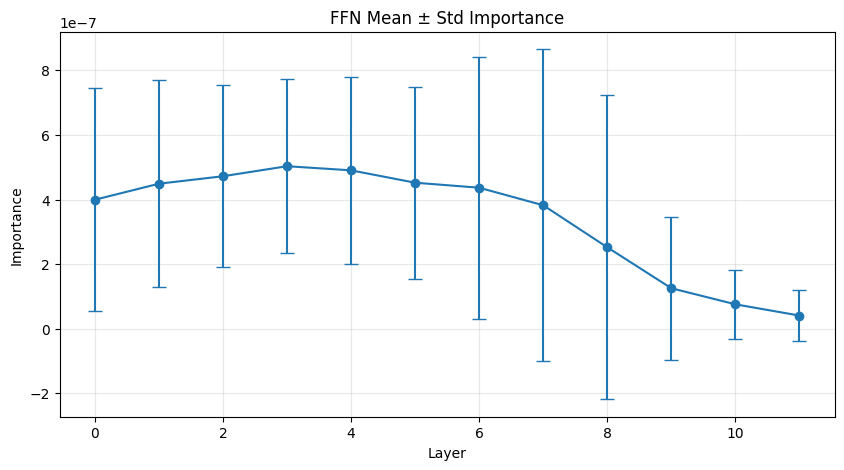

In [53]:
plot_ffn_mean_std(neuron_imp)